In [15]:
# ==============================================================================
# STUDENT DETAILS
# ==============================================================================
print(f"Student Name: kathiravan ")
print(f"Student Roll No: 24BAD057")

# Import required libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Download required NLTK resources
nltk.download('stopwords')
print("\nLibraries imported successfully!")

Student Name: kathiravan 
Student Roll No: 24BAD057

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Shape: (50000, 2)

First 5 rows of the dataset:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

--- SAMPLE POSITIVE REVIEW ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

--- SAMPLE NEGATIVE REVIEW ---
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly

/tmp/ipykernel_8641/2511297351.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='coolwarm')


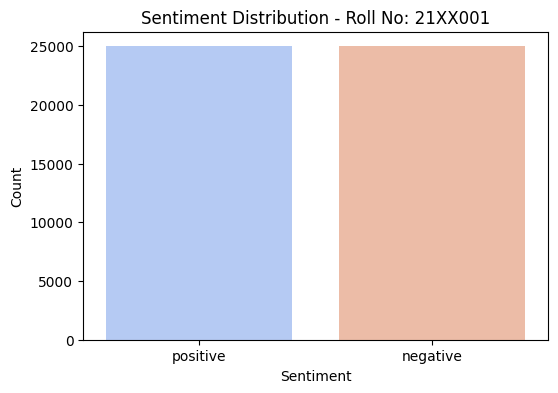

In [3]:
# Load IMDB Dataset directly from a working GitHub mirror
dataset_url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
print("Downloading and loading dataset...")
df = pd.read_csv(dataset_url)

# Display dataset details
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Examine sample positive and negative reviews
print("\n--- SAMPLE POSITIVE REVIEW ---")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:300], "...")

print("\n--- SAMPLE NEGATIVE REVIEW ---")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:300], "...")

# Check class distribution
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='coolwarm')
plt.title(f"Sentiment Distribution - Roll No: {STUDENT_ROLL_NO}")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [4]:
# Load English stop words from NLTK
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Cleans raw text by:
    1. Lowercasing
    2. Removing HTML tags
    3. Removing special characters & numbers
    4. Removing stop words
    """
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # 3. Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Remove stop words
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]

    return " ".join(filtered_words)

# Apply preprocessing (Using a sample subset of 10,000 for faster demonstration in lab environments)
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)

print("Preprocessing dataset (Lowercasing, Punctuation/Stopword Removal)...")
df_sample['cleaned_review'] = df_sample['review'].apply(preprocess_text)

print("\nOriginal vs Cleaned Review Example:")
print("Original:", df_sample['review'].iloc[0][:150])
print("Cleaned :", df_sample['cleaned_review'].iloc[0][:150])

Preprocessing dataset (Lowercasing, Punctuation/Stopword Removal)...

Original vs Cleaned Review Example:
Original: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th
Cleaned : really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslams ever wwf didnt lex luger main event


PART-A

In [5]:
# Constants
MAX_WORDS = 10000   # Maximum vocabulary size
MAX_LEN = 100       # Maximum sequence length for padding

# Tokenize text
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_sample['cleaned_review'])

# Convert text into numerical integer sequences
sequences = tokenizer.texts_to_sequences(df_sample['cleaned_review'])

# Pad sequences to equal length
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Encode targets: 'positive' -> 1, 'negative' -> 0
y = df_sample['sentiment'].map({'positive': 1, 'negative': 0}).values

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Padded Input Sequence Shape: {X_padded.shape}")
print(f"Training Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}, Labels Shape: {y_test.shape}")

Vocabulary Size: 68051
Padded Input Sequence Shape: (10000, 100)
Training Set Shape: (8000, 100), Labels Shape: (8000,)
Testing Set Shape:  (2000, 100), Labels Shape: (2000,)


PART B

In [6]:
EMBEDDING_DIM = 64  # Vector dimension for word representation

# Demonstrate how Keras Embedding layer transforms sequences
sample_embedding_layer = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)

# Pass a small batch of padded training sequences through the embedding layer
sample_batch = X_train[:2]
dense_vector_representation = sample_embedding_layer(sample_batch)

print(f"--- PART B: EMBEDDING GENERATION ---")
print(f"Student Roll No : {STUDENT_ROLL_NO}")
print(f"Vocabulary Size : {MAX_WORDS}")
print(f"Embedding Dim   : {EMBEDDING_DIM}")
print(f"Input Seq Shape : {sample_batch.shape}")
print(f"Output Vector   : {dense_vector_representation.shape}")

# Explanation of dense representation
print("\nAnalysis of Word Embeddings:")
print("1. Each word index is mapped to a continuous dense vector of dimension 64.")
print("2. Words with similar contextual meanings learn close distance representations in this vector space during training.")

--- PART B: EMBEDDING GENERATION ---
Student Roll No : 21XX001
Vocabulary Size : 10000
Embedding Dim   : 64
Input Seq Shape : (2, 100)
Output Vector   : (2, 100, 64)

Analysis of Word Embeddings:
1. Each word index is mapped to a continuous dense vector of dimension 64.
2. Words with similar contextual meanings learn close distance representations in this vector space during training.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


PART C

In [14]:
from tensorflow.keras.layers import Input

# Build Sequential LSTM Network
model = Sequential([
    # Explicit Input layer (resolves the 'unbuilt' issue)
    Input(shape=(MAX_LEN,)),

    # Embedding Layer
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(0.2),

    # Recurrent Layer (LSTM)
    LSTM(units=64, dropout=0.2, recurrent_dropout=0.2),

    # Dense Output Layer
    Dense(units=1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
print(f"=== MODEL ARCHITECTURE (Roll No: {STUDENT_ROLL_NO}) ===")
model.summary()

=== MODEL ARCHITECTURE (Roll No: 21XX001) ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

PART D

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 10  # Increased since early stopping will halt it automatically
BATCH_SIZE = 64

# Stop training when validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the LSTM model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.6934 - loss: 0.5436 - val_accuracy: 0.6535 - val_loss: 0.6070
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.8199 - loss: 0.4018 - val_accuracy: 0.7810 - val_loss: 0.5288
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.8929 - loss: 0.2796 - val_accuracy: 0.7850 - val_loss: 0.5658
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.9273 - loss: 0.2033 - val_accuracy: 0.8125 - val_loss: 0.5006
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.9500 - loss: 0.1477 - val_accuracy: 0.8130 - val_loss: 0.5665
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - accuracy: 0.9632 - loss: 0.1158 - val_accuracy: 0.8100 - val_loss: 0.5873


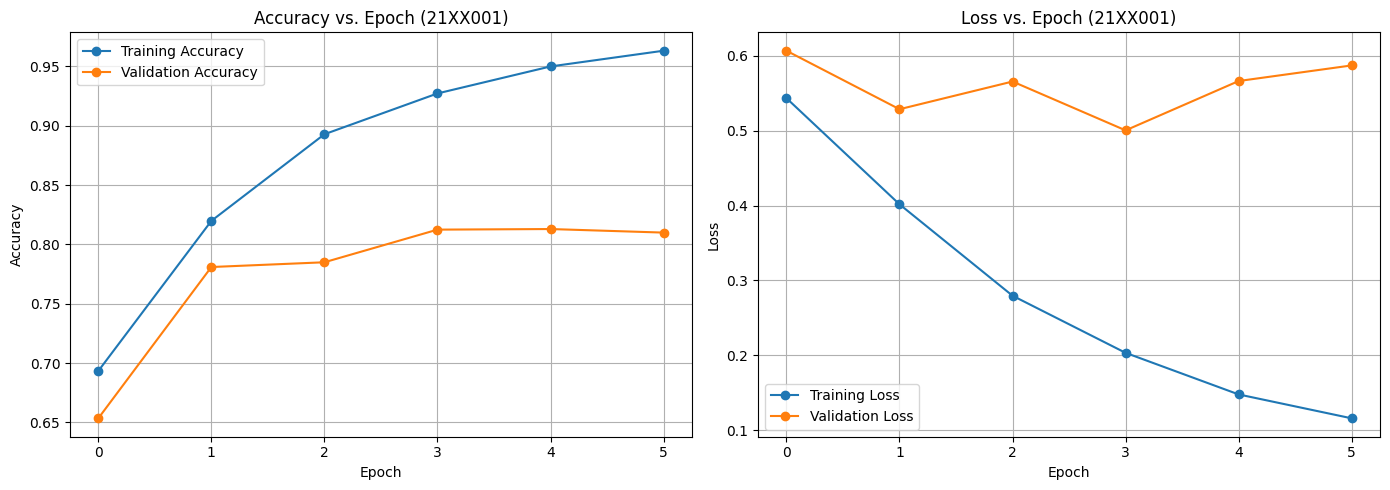

In [10]:
# Plot Accuracy and Loss vs. Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
ax1.set_title(f'Accuracy vs. Epoch ({STUDENT_ROLL_NO})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title(f'Loss vs. Epoch ({STUDENT_ROLL_NO})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step
=== EVALUATION METRICS (Roll No: 21XX001) ===
Accuracy  : 0.8125
Precision : 0.7955
Recall    : 0.8452
F1-Score  : 0.8196

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.78      0.80       992
    Positive       0.80      0.85      0.82      1008

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



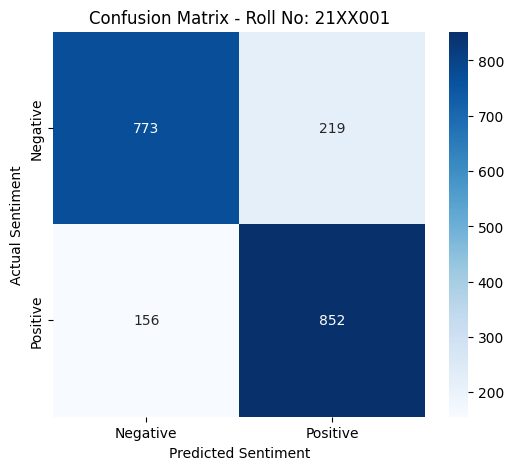

In [11]:
# Predict probabilities on test data
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# Compute Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"=== EVALUATION METRICS (Roll No: {STUDENT_ROLL_NO}) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}\n")

# Display Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title(f"Confusion Matrix - Roll No: {STUDENT_ROLL_NO}")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [12]:
def predict_sentiment(review_text):
    """Preprocesses input text, tokenizes, pads, and predicts sentiment."""
    cleaned = preprocess_text(review_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prob >= 0.5 else "Negative"
    return sentiment, prob

# Test Sample Reviews
sample_reviews = [
    "The movie was absolutely fantastic! Brilliant acting and incredible cinematography.",
    "Boring and predictable plot. The actors felt totally uninspired and wasted my time.",
    "It was an average film. Some scenes were decent, but overall it lacked depth."
]

actual_sentiments = ["Positive", "Negative", "Negative/Neutral"]

print(f"=== SENTIMENT PREDICTIONS (Roll No: {STUDENT_ROLL_NO}) ===\n")
for review, actual in zip(sample_reviews, actual_sentiments):
    pred_sentiment, prob = predict_sentiment(review)
    print(f"Review   : \"{review}\"")
    print(f"Actual   : {actual}")
    print(f"Predicted: {pred_sentiment} (Confidence Score: {prob:.4f})")
    print("-" * 75)

=== SENTIMENT PREDICTIONS (Roll No: 21XX001) ===

Review   : "The movie was absolutely fantastic! Brilliant acting and incredible cinematography."
Actual   : Positive
Predicted: Positive (Confidence Score: 0.9310)
---------------------------------------------------------------------------
Review   : "Boring and predictable plot. The actors felt totally uninspired and wasted my time."
Actual   : Negative
Predicted: Negative (Confidence Score: 0.0834)
---------------------------------------------------------------------------
Review   : "It was an average film. Some scenes were decent, but overall it lacked depth."
Actual   : Negative/Neutral
Predicted: Negative (Confidence Score: 0.1486)
---------------------------------------------------------------------------
